# TME ML Non supervisé

Pair work between: Milos Oundjian, Vladislav Antipin

In [1]:
import pandas as pd
import sklearn
import numpy as np
import matplotlib.pyplot as plt

# K-Means et Geographical clustering

## 1- Data preparation

<div class="alert alert-block alert-info">
For this section, we will use the points of interest (POI) data of Paris. The objective is to spatially characterize the urban space of Paris based on the POIs present in a region. Clustering the regions thus highlights similar areas and the reasons for their similarity (by analyzing the prototype of each cluster).

The following lines allow you to draw the districts of Paris from the <code>districts-paris.csv</code> file and to load the POIs (from the <code>poi-paris.csv</code> file).
</div>


In [2]:
table_poi = pd.read_csv("data/poi-paris.csv")
districts = pd.read_csv("data/districts-paris.csv", sep=",")
districts["bounds"] = districts["bounds"].apply(eval)


#  Draw the districts
def draw_districts():
    for x in districts["bounds"]:
        plt.plot([c[0] for c in x], [c[1] for c in x], color="black")

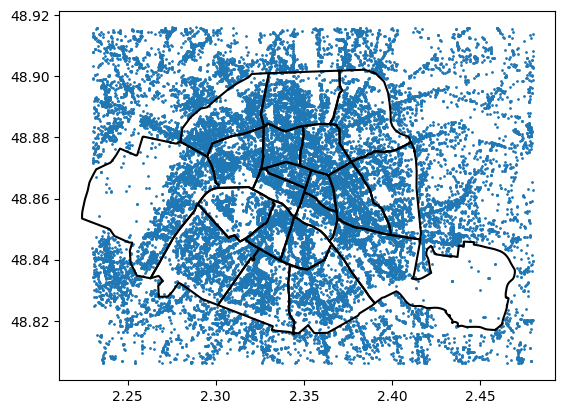

In [3]:
plt.scatter(table_poi["longitude"], table_poi["latitude"], s=1)
draw_districts()

### 2 - Discrétisation manuelle de l'espace

<div class="alert alert-block alert-info">

We cannot use the natural discretization of the districts because it is too coarse and groups together sub-regions of very different types. One initial approach to obtain interesting sub-regions in Paris is to manually discretize using a grid. We will assume a regular grid of size $N$.

Thus, for a GPS coordinate $(\text{long},\text{lat})$, we need to know which grid cell $(i,j)$ it corresponds to. For a grid of size $N \times N$, the formula is as follows: 

$$
i = \lfloor N \cdot \frac{(longitude-lomin)}{(lomax-lomin)} \rfloor
$$ 

and 

$$
j = \lfloor N*\frac{(latitude - lamin)}{(lamax-lamin)} \rfloor,
$$

with $\lfloor x\rfloor$ denoting the integer part of $x$, $lamin,lamax$ the minimum and maximum latitudes, and $lomin,lomax$ the minimum and maximum longitudes.

Each grid cell will be described by the distribution of the types of POIs present in the corresponding area. There are 12 types of POIs, so each cell is described by a 12-dimensional vector, where each dimension indicates the probability of the type associated with that dimension in the region.
    
Compute the description associated with each cell. 

Run a k-means algorithm on it (using <code>KMeans</code> from scikit-learn, where <code>n_clusters</code> sets the number of clusters; the <code>fit()</code> method performs the clustering; the <code>predict()</code> method obtains the cluster associated with each example; and the <code>fit_predict()</code> method does both at the same time).

Also, visualize the centroids of the clusters. Vary the number of clusters and compare the results.

The following code graphically represents the computed clustering (with <code>get_clust(i,j)</code> returning the cluster number associated with cell $(i,j)$) and plots the centroids (from a KMeans stored in the variable <code>km</code>).
</div>


In [4]:
def describe_cell():
    pass

In [5]:
lomin = table_poi["longitude"].min()
lomax = table_poi["longitude"].max()

lamin = table_poi["latitude"].min()
lamax = table_poi["latitude"].max()

In [6]:
N = 15
table_poi["i"] = np.floor(N * (table_poi["longitude"] - lomin) / (lomax - lomin))
table_poi["j"] = np.floor(N * (table_poi["latitude"] - lamin) / (lamax - lamin))
table_poi[["i", "j"]]

,i,j
0,6.0,8.0
1,6.0,13.0
2,8.0,5.0
3,4.0,10.0
4,4.0,2.0
...,...,...
31847,11.0,7.0
31848,9.0,14.0
31849,6.0,9.0
31850,3.0,14.0


In [7]:
types = [
    "furniture_store",
    "laundry",
    "bakery",
    "cafe",
    "home_goods_store",
    "clothing_store",
    "atm",
    "lodging",
    "night_club",
    "convenience_store",
    "restaurant",
    "bar",
]


def get_distributions_grid():
    def get_distribution(i, j):
        distribution = np.ones(12) * 1e-5
        for c, category in enumerate(types):
            distribution[c] += table_poi[(table_poi["i"] == i) & (table_poi["j"] == j)][
                category
            ].sum()
        distribution /= distribution.sum()
        return distribution

    distributions = np.empty((N * N, 12))
    for i in range(N):
        for j in range(N):
            distributions[i * N + j] = get_distribution(i, j)
    return distributions


descriptions = get_distributions_grid()

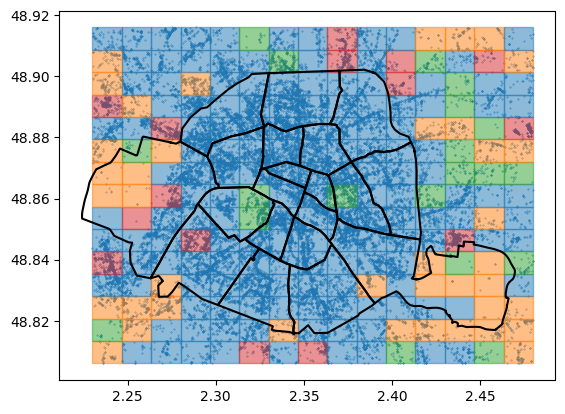

In [8]:
from matplotlib.patches import Rectangle

from sklearn.cluster import KMeans

n_clusters = 4
km = KMeans(n_clusters=n_clusters)
clusters = km.fit_predict(descriptions)

tab10 = plt.colormaps["tab10"]


def get_clust(i, j):
    return clusters[i * N + j]


_ = plt.scatter(table_poi["longitude"], table_poi["latitude"], s=0.1)
draw_districts()
for i in range(N):
    for j in range(N):
        x = lomin + (lomax - lomin) * i / N
        y = lamin + (lamax - lamin) * j / N
        c = tab10.colors[get_clust(i, j)]
        _ = plt.gca().add_patch(
            Rectangle(
                (x, y), (lomax - lomin) / N, (lamax - lamin) / N, color=c, alpha=0.5
            )
        )


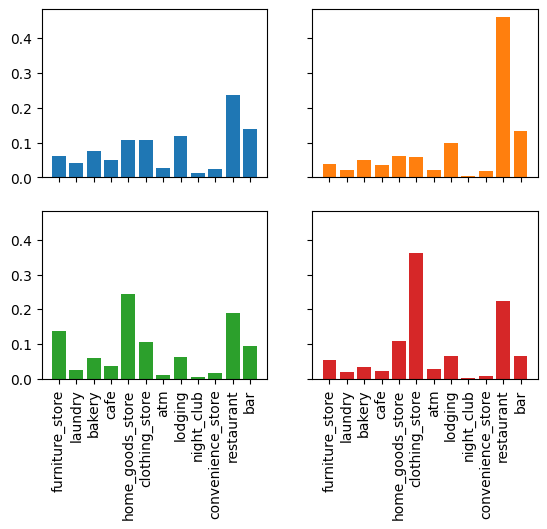

In [9]:
fig, axs = plt.subplots(len(km.cluster_centers_) // 2, 2, sharey=True, sharex=True)
for i, k in enumerate(km.cluster_centers_):
    axs.flatten()[i].bar(range(len(k)), k, color=tab10.colors[i])
    axs.flatten()[i].set_xticks(range(len(k)))
    axs.flatten()[i].set_xticklabels(types, rotation="vertical")

<div class="alert alert-block alert-info">
The model's elbow score corresponds to the model's <em>inertia_</em> attribute. Plot the elbow curve as a function of the number of clusters. What is the optimal number of clusters according to this curve?
</div>


## 3 -  K-Means pour la discrétisation automatique de l'espace

<div class="alert alert-block alert-info">
To obtain more relevant clusters, the discretization of space must be done in a less naive way. One idea is also to use the $K$-means algorithm for this, by clustering the GPS coordinates of the POIs (which is also called a <em>quantization</em>). 
</br>
Calculate this spatial clustering and assign each POI a spatial cluster number (note: a grid of size $10\times 10$ is "equivalent" to having 100 clusters).

Graphically represent the clusters thus obtained using the following lines of code (<code>get_cluster_spatial(i)</code> returns the cluster of the $i$-th POI, and the KMeans model is stored in the variable <code>km_spatial</code>).

Perform clustering on this new discretization and compare your results.

Observe the correlation between the types in the initial data. Can you propose a method to improve the results?
</div>


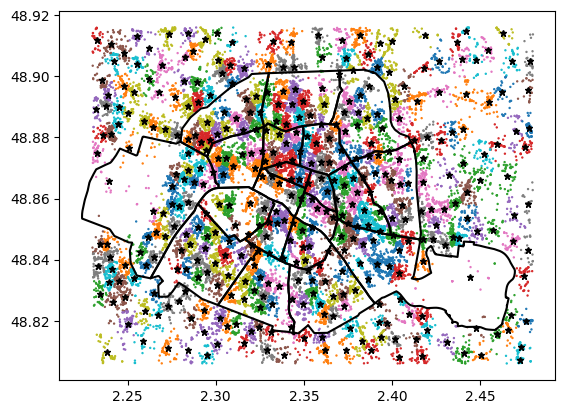

In [10]:
K_GEO = 400
km_spatial = KMeans(n_clusters=K_GEO)
table_poi["cluster"] = km_spatial.fit_predict(table_poi[["longitude", "latitude"]])


def get_cluster_spatial(i):
    return table_poi["cluster"][i]


draw_districts()
plt.scatter(
    table_poi["longitude"],
    table_poi["latitude"],
    color=[tab10.colors[get_cluster_spatial(i) % 10] for i in range(len(table_poi))],
    s=0.5,
)
for i in range(K_GEO):
    plt.plot(
        km_spatial.cluster_centers_[i, 0],
        km_spatial.cluster_centers_[i, 1],
        marker="*",
        color="black",
        markersize=5,
    )

In [11]:
def get_distributions_cluster(n_clusters):
    def get_distribution(cluster):
        distribution = np.ones(12) * 1e-5
        for c, category in enumerate(types):
            distribution[c] += table_poi[table_poi["cluster"] == cluster][
                category
            ].sum()
        distribution /= distribution.sum()
        return distribution

    distributions = np.empty((n_clusters, 12))
    for i in range(n_clusters):
        distributions[i] = get_distribution(i)
    return distributions


descriptions_clustered = get_distributions_cluster(n_clusters=K_GEO)

In [12]:
descriptions_clustered

array([[3.59712639e-02, 6.47482175e-02, 2.15827871e-02, ...,
        2.15827871e-02, 3.16546561e-01, 1.65467555e-01],
       [2.27273140e-02, 5.68181431e-08, 5.68181999e-02, ...,
        1.13636854e-02, 2.44318072e-01, 2.10227186e-01],
       [9.52380816e-02, 1.90476925e-02, 4.76190884e-02, ...,
        9.52389388e-03, 2.76190256e-01, 1.80952269e-01],
       ...,
       [3.92157382e-02, 4.90196482e-02, 2.94118281e-02, ...,
        4.90196482e-02, 1.96078299e-01, 1.17647018e-01],
       [2.77778704e-02, 4.16667361e-02, 5.55556019e-02, ...,
        1.38888657e-07, 2.08333125e-01, 5.55556019e-02],
       [7.27272804e-02, 5.45454755e-02, 9.69696871e-02, ...,
        4.84848738e-02, 1.87878712e-01, 1.21212094e-01]], shape=(400, 12))

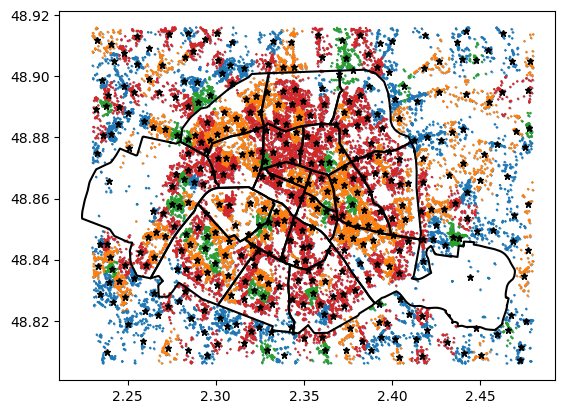

In [13]:
n_clusters = 4
km = KMeans(n_clusters=n_clusters)
clusters = km.fit_predict(descriptions_clustered)

tab10 = plt.colormaps["tab10"]


_ = plt.scatter(table_poi["longitude"], table_poi["latitude"], s=0.1)

draw_districts()
plt.scatter(
    table_poi["longitude"],
    table_poi["latitude"],
    color=[
        tab10.colors[clusters[get_cluster_spatial(i)] % 10]
        for i in range(len(table_poi))
    ],
    s=0.5,
)
for i in range(K_GEO):
    plt.plot(
        km_spatial.cluster_centers_[i, 0],
        km_spatial.cluster_centers_[i, 1],
        marker="*",
        color="black",
        markersize=5,
    )

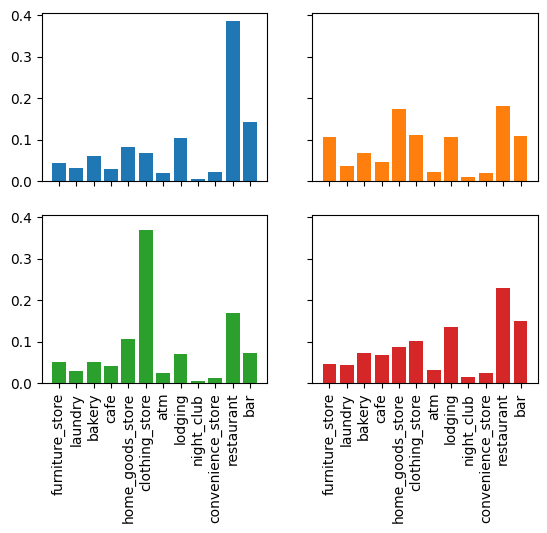

In [14]:
fig, axs = plt.subplots(len(km.cluster_centers_) // 2, 2, sharey=True, sharex=True)
for i, k in enumerate(km.cluster_centers_):
    axs.flatten()[i].bar(range(len(k)), k, color=tab10.colors[i])
    axs.flatten()[i].set_xticks(range(len(k)))
    axs.flatten()[i].set_xticklabels(types, rotation="vertical")